# 03. Fine-Tuning LegalBERT for Clause Classification

## Executive Summary & Training Objectives
This notebook trains and evaluates our fine-tuned transformer classifier (**`nlpaueb/legal-bert-base-uncased`**) on the ClauseGuard 10-class Employment Contract Dataset.

### Training Setup:
- **Base Architecture:** `nlpaueb/legal-bert-base-uncased` + 10-class linear classification head (`Linear(768 -> 10)`).
- **Input Features:** `clause_text` (truncated at `max_length=256`).
- **Dynamic Batch Padding:** `DataCollatorWithPadding` (dynamically pads each batch to its longest sequence instead of fixed 256 padding, speeding up training by ~2-3x).
- **Target Labels:** 10 Employment categories (`label_id` 0 to 9).
- **Splits:** 0-leakage document-grouped `train.csv`, `val.csv`, `test.csv` from `ml/data/employment_processed/`.
- **Evaluation Metrics:** Accuracy, Precision, Recall, Weighted-F1, Macro-F1, Per-Class Classification Report, and Confusion Matrix.

## 1. Environment & GPU Verification

In [2]:
!pip install -U transformers datasets accelerate evaluate scikit-learn

  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.34.4
    Uninstalling huggingface-hub-0.34.4:
      Successfully uninstalled huggingface-hub-0.34.4
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.6.2
    Uninstalling safetensors-0.6.2:
      Successfully uninstalled safetensors-0.6.2
  Attempting uninstall: regex
    Found existing installation: regex 2025.7.34
    Uninstalling regex-2025.7.34:
      Successfully uninstalled regex-2025.7.34
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.18.0 which is incompatible.
You should consider upgrading via the 'C:\Users\LENOVO\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import torch
from pathlib import Path

print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))
    print("VRAM Capacity:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("WARNING: Running on CPU. Training will take longer.")

Python Version: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
PyTorch Version: 2.14.1+cu126
CUDA Available: True
GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM Capacity: 6.44 GB


In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.18.0 which is incompatible.
You should consider upgrading via the 'C:\Users\LENOVO\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.



  Using cached https://download-r2.pytorch.org/whl/cu126/torch-2.14.1%2Bcu126-cp310-cp310-win_amd64.whl (2602.8 MB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchvision-0.29.1%2Bcu126-cp310-cp310-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchaudio-2.11.0%2Bcu126-cp310-cp310-win_amd64.whl (1.5 MB)


## 2. Load Processed Employment Datasets & Label Mapping

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "ml" / "data" / "employment_augmented"
if not DATA_DIR.exists():
    DATA_DIR = Path("ml/data/employment_processed")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

with open(DATA_DIR / "label_mapping.json", "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

id2label = {int(k): v for k, v in label_mapping["id2label"].items()}
label2id = {k: int(v) for k, v in label_mapping["label2id"].items()}

print(f"Train Shape: {train_df.shape}")
print(f"Val Shape:   {val_df.shape}")
print(f"Test Shape:  {test_df.shape}")
print("\nClass Label Mapping:")
for idx in range(len(id2label)):
    count = (train_df["label_id"] == idx).sum()
    print(f"  ID {idx}: {id2label[idx]:22s} ({count:4d} train clauses)")

Train Shape: (2478, 7)
Val Shape:   (522, 7)
Test Shape:  (539, 7)

Class Label Mapping:
  ID 0: confidentiality        (  41 train clauses)
  ID 1: exclusivity            ( 290 train clauses)
  ID 2: governing_law          ( 312 train clauses)
  ID 3: ip_assignment          ( 295 train clauses)
  ID 4: liability_indemnity    ( 483 train clauses)
  ID 5: no_solicit_customers   (  66 train clauses)
  ID 6: no_solicit_employees   (  69 train clauses)
  ID 7: non_compete            ( 180 train clauses)
  ID 8: other_general          ( 505 train clauses)
  ID 9: termination_notice     ( 237 train clauses)


## 3. Convert Pandas DataFrames to Hugging Face Datasets

In [3]:
from datasets import Dataset

# Ensure text and label columns match HF Trainer requirements
def prepare_hf_df(df):
    return df.rename(columns={"clause_text": "text", "label_id": "labels"})[["text", "labels"]]

train_dataset = Dataset.from_pandas(prepare_hf_df(train_df), preserve_index=False)
val_dataset = Dataset.from_pandas(prepare_hf_df(val_df), preserve_index=False)
test_dataset = Dataset.from_pandas(prepare_hf_df(test_df), preserve_index=False)

print("Sample Hugging Face Dataset Record:")
print(train_dataset[0])

c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample Hugging Face Dataset Record:
{'text': 'This Agreement is to be construed according to the laws of the State of Illinois.', 'labels': 2}


## 4. Load LegalBERT Tokenizer & Create DataCollatorWithPadding (Dynamic Padding)

In [4]:
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
print(f"[*] Loading LegalBERT Tokenizer from: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Truncate at 256 tokens, but defer padding to the DataCollator dynamically per batch!
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

print("[*] Tokenizing Train, Val, and Test sets (truncation max_length=256)...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Dynamic Data Collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("[✓] Tokenization complete with Dynamic Batch DataCollator!")

[*] Loading LegalBERT Tokenizer from: nlpaueb/legal-bert-base-uncased...
[*] Tokenizing Train, Val, and Test sets (truncation max_length=256)...


Map: 100%|██████████| 539/539 [00:00<00:00, 18037.64 examples/s]

[✓] Tokenization complete with Dynamic Batch DataCollator!


## 5. Load Pre-trained LegalBERT Sequence Classifier Model

In [5]:
from transformers import AutoModelForSequenceClassification

print(f"[*] Initializing LegalBERT Model for 10-class Sequence Classification...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
)

print("[✓] Model initialized with 10 classification logits!")

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `2`.


[*] Initializing LegalBERT Model for 10-class Sequence Classification...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25572.67it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different tas

[✓] Model initialized with 10 classification logits!


## 6. Define Evaluation Metrics (Accuracy, Macro-F1, Weighted-F1)

In [6]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, predictions)
    w_prec, w_rec, w_f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted", zero_division=0)
    m_prec, m_rec, m_f1, _ = precision_recall_fscore_support(labels, predictions, average="macro", zero_division=0)
    
    return {
        "accuracy": acc,
        "f1": w_f1,
        "macro_f1": m_f1,
        "precision": w_prec,
        "recall": w_rec
    }

In [9]:
print(next(model.parameters()).device)
from huggingface_hub import scan_cache_dir

cache = scan_cache_dir()

for repo in cache.repos:
    print(repo.repo_id)
    print(repo.repo_path)

cpu
nlpaueb/legal-bert-base-uncased
C:\Users\LENOVO\.cache\huggingface\hub\models--nlpaueb--legal-bert-base-uncased
distilbert-base-uncased
C:\Users\LENOVO\.cache\huggingface\hub\models--distilbert-base-uncased
Salesforce/blip-image-captioning-base
C:\Users\LENOVO\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base
sentence-transformers/all-MiniLM-L6-v2
C:\Users\LENOVO\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2
bert-base-uncased
C:\Users\LENOVO\.cache\huggingface\hub\models--bert-base-uncased
theatticusproject/cuad
C:\Users\LENOVO\.cache\huggingface\hub\datasets--theatticusproject--cuad


## 7. Configure Training Hyperparameters & Trainer with Dynamic DataCollator

In [12]:
from transformers import TrainingArguments, Trainer

output_dir = PROJECT_ROOT / "ml" / "artifacts" / "legalbert_classifier"
output_dir.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir=str(output_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("[✓] Trainer configured successfully with DataCollatorWithPadding!")

[✓] Trainer configured successfully with DataCollatorWithPadding!


## 8. Train LegalBERT Model

In [13]:
print("[*] Starting LegalBERT Training with Dynamic Batch Padding...")
train_result = trainer.train()
print("[✓] Training Completed!")

[*] Starting LegalBERT Training with Dynamic Batch Padding...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Macro F1,Precision,Recall
1,0.312394,0.309778,0.911877,0.911857,0.872639,0.914788,0.911877
2,0.247753,0.444395,0.904215,0.904450,0.870985,0.908859,0.904215
3,0.220662,0.442459,0.902299,0.901608,0.871110,0.904639,0.902299
4,0.132716,0.457164,0.908046,0.907240,0.872697,0.910117,0.908046
5,0.109210,0.476047,0.904215,0.904505,0.866406,0.908618,0.904215


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]


[✓] Training Completed!


## 9. Evaluate on Test Set & Generate Per-Class Classification Report

[*] Evaluating fine-tuned LegalBERT on Test Set...



=== Classification Report ===
                      precision    recall  f1-score   support

     confidentiality     0.7500    0.7500    0.7500        12
         exclusivity     0.7143    0.8511    0.7767        47
       governing_law     0.9571    1.0000    0.9781        67
       ip_assignment     0.9048    0.9048    0.9048        63
 liability_indemnity     0.9612    0.9323    0.9466       133
no_solicit_customers     0.4615    0.6000    0.5217        10
no_solicit_employees     1.0000    0.7692    0.8696        13
         non_compete     0.7742    0.6000    0.6761        40
       other_general     0.8737    0.9022    0.8877        92
  termination_notice     0.9667    0.9355    0.9508        62

            accuracy                         0.8868       539
           macro avg     0.8364    0.8245    0.8262       539
        weighted avg     0.8914    0.8868    0.8870       539



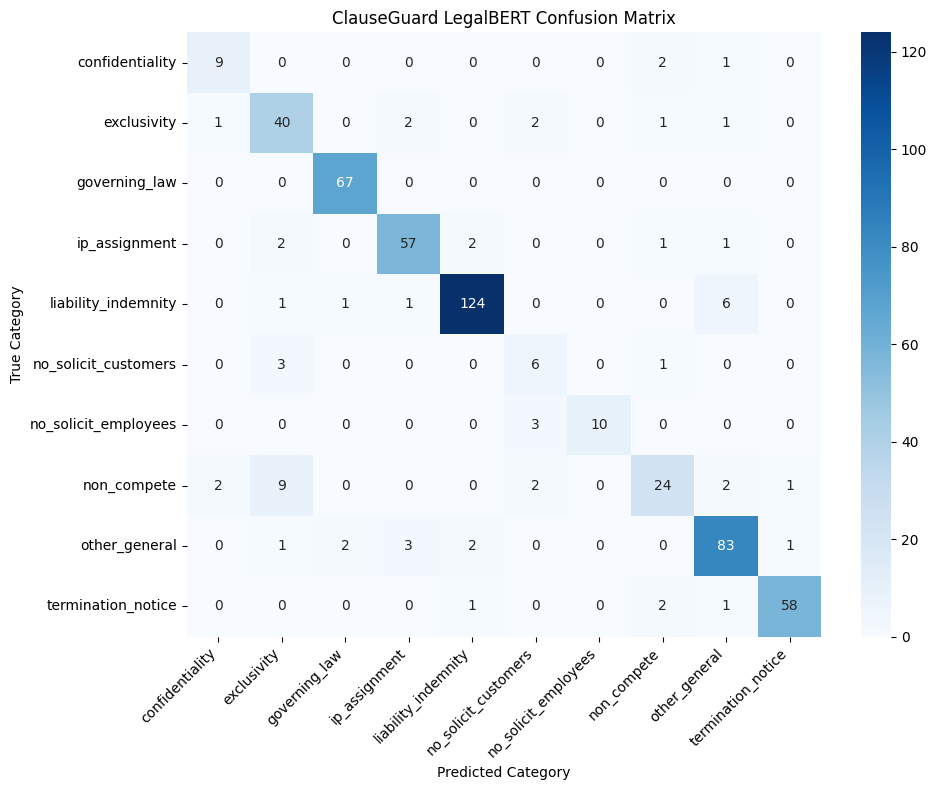

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print("[*] Evaluating fine-tuned LegalBERT on Test Set...")
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

target_names = [id2label[i] for i in range(len(id2label))]
print("\n=== Classification Report ===")
print(classification_report(labels, preds, target_names=target_names, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("ClauseGuard LegalBERT Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

## 10. Test Real-World Inference on Employment Clauses

In [15]:
def predict_clause_category(clause_text, model, tokenizer, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.to(device)
    model.eval()
    
    inputs = tokenizer(clause_text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        
    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_id = probs.argmax(dim=-1).item()
    confidence = probs[0, predicted_id].item()
    
    return id2label[predicted_id], confidence

# Sample test clauses
test_clauses = [
    "The Employee agrees that for a period of twelve months following termination, they shall not engage in any competing software business.",
    "During employment and for one year thereafter, the Executive will not directly encourage or solicit any employee to leave the Company.",
    "This Agreement shall be governed by and construed in accordance with the laws of the State of New York.",
    "All inventions, improvements, and patent rights developed during employment shall belong solely to the Employer.",
    "Either party may terminate this agreement at any time by providing 30 days prior written notice."
]

print("=== Real-World LegalBERT Predictions ===\n")
for text in test_clauses:
    cat, conf = predict_clause_category(text, model, tokenizer)
    print(f"Text: '{text}'")
    print(f" -> Predicted Class: {cat} (Confidence: {conf:.2%})\n")

=== Real-World LegalBERT Predictions ===

Text: 'The Employee agrees that for a period of twelve months following termination, they shall not engage in any competing software business.'
 -> Predicted Class: non_compete (Confidence: 99.22%)

Text: 'During employment and for one year thereafter, the Executive will not directly encourage or solicit any employee to leave the Company.'
 -> Predicted Class: no_solicit_employees (Confidence: 98.64%)

Text: 'This Agreement shall be governed by and construed in accordance with the laws of the State of New York.'
 -> Predicted Class: governing_law (Confidence: 99.80%)

Text: 'All inventions, improvements, and patent rights developed during employment shall belong solely to the Employer.'
 -> Predicted Class: ip_assignment (Confidence: 99.78%)

Text: 'Either party may terminate this agreement at any time by providing 30 days prior written notice.'
 -> Predicted Class: termination_notice (Confidence: 99.66%)



In [6]:
# Target category to inspect
target_class = "no_solicit_customers"

# Get the numeric ID from your label_mapping.json (label2id dict)
target_id = label_mapping["label2id"][target_class]

# Filter test_df using your column name "clause_text"
customer_clauses = train_df[
    train_df["label_id"] == target_id
][["clause_text", "label_id", "employment_category"]]

print(f"Number of '{target_class}' test examples: {len(customer_clauses)}")

# Display each clause
for i, row in customer_clauses.reset_index(drop=True).iterrows():
    print(f"\n--- Example {i + 1} ({row['employment_category']}) ---")
    print(row["clause_text"])


Number of 'no_solicit_customers' test examples: 40

--- Example 1 (no_solicit_customers) ---
Distributor further agrees that it will not interfere with or otherwise disrupt the business relations between the Company or nay of its affiliates and any of their current or prospective customers, suppliers or distributors, during the

--- Example 2 (no_solicit_customers) ---
Term of the Agreement and for a period of eighteen (18) months thereafter, nor will Distributor solicit any customer or potential customer of Company to purchase a competitive product during that period.

--- Example 3 (no_solicit_customers) ---
Member covenants and agrees that during the term of the Franchise Agreement, except as otherwise approved in writing by Franchisor, Member shall not, either directly or indirectly, for itself, or through, on behalf of, or in conjunction with any person, persons, partnership, corporation, or entity:

--- Example 4 (no_solicit_customers) ---
(ii) Divert or attempt to divert any bus